# TiTiler-CMR Compatibility Report

## What Datasets are Compatible with TiTiler-CMR? 

This report details TiTiler-CMR compatible and incompatible datasets.

## What is tested?

TiTiler-CMR has `/tiles` and `/statistics` groups of endpoints, with `/timeseries/statistics` being an expansion of the `/statistics` group. The `/tiles` and `/statistics` endpoints read data from source files. Some files work with TiTiler-CMR and some do not; the reasons are detailed in this report. While datasets compatible with tiling are highly likely to also be compatible with statistics, this report only covers **tiling** compatibility.

This report provides:

1. A searchable listing of NASA EOSDIS datasets and whether they have been found to be compatible or incompatible with TiTiler-CMR's **tiling** endpoints.
2. An overview of the **types of datasets** that were to be compatible and incompatible.

See [titiler-cmr-compatibility's METHODOLOGY](https://github.com/developmentseed/titiler-cmr-compatibility/blob/main/METHODOLOGY.md) documentation for a detailed explanation of how datasets were tested.

## What datasets are compatible?

In [1]:
import pandas as pd
import plotting
from IPython.display import display, Markdown

df = pd.read_parquet("tiling_results-11-24-2025.parquet")
num_all_datasets = len(df)
compatible_datasets = df[df.tiling_compatible]
num_compatible_datasets = len(compatible_datasets)

display(
    Markdown(
        f"Out of {num_all_datasets} datasets tested, **{num_compatible_datasets} were found to be compatible**."
    )
)

Out of 10047 datasets tested, **719 were found to be compatible**.

### Searchable Dataset Table

To search across all datasets (where a granule was found) and check compatibility status, view the interactive table:

**[→ View Interactive Dataset Table](results_table.html)**

To determine if a particular dataset is compatible, search for it by name and check the `Tiling Compatible` column.

To regenerate the table, run the [`generate_table.py`](https://github.com/developmentseed/titiler-cmr/blob/develop/docs/compatibility/generate_table.py) script.

## What types of datasets are compatible?

* GES_DISC, PODAAC, ORNLDAAC and OBDAAC have the most compatible datasets.
* Most compatible datasets are processing level 3 or 4.
* Most compatible datasets are NetCDF-4 format, however ~200 are Cloud-Optimized GeoTIFFs (COGs).

Now for some 🥧 charts.

### Compatible Datasets by Data Center

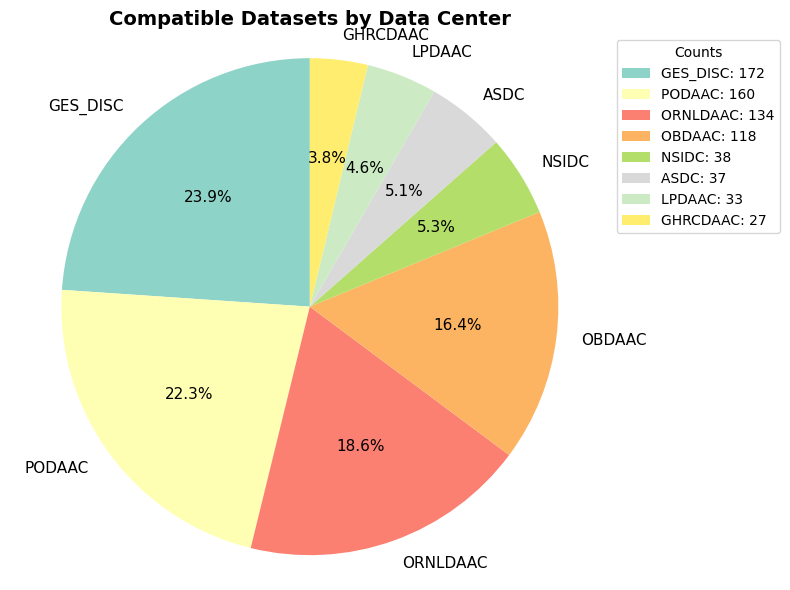

In [2]:
data_center_counts = compatible_datasets.data_center.value_counts(dropna=False)
data_center_names = data_center_counts.index

plotting.create_pie_chart(
    labels=data_center_names,
    sizes=data_center_counts,
    title="Compatible Datasets by Data Center",
    legend=True,
)

### Percentage of compatible datasets by data center

In [3]:
result = df.groupby("data_center")["tiling_compatible"].mean() * 100
result = result.map("{:.2f}%".format)
result.reset_index().rename(
    columns={
        "data_center": "Data Center",
        "tiling_compatible": "% Tiling-Compatible Datasets",
    }
)

,Data Center,% Tiling-Compatible Datasets
0,ASDC,2.22%
1,ASF,0.00%
2,GES_DISC,10.09%
3,GHRCDAAC,4.27%
4,LAADS,0.00%
5,LPDAAC,5.28%
6,NSIDC,6.57%
7,OBDAAC,13.79%
8,ORNLDAAC,7.29%
9,PODAAC,18.35%


### Compatible Datasets by Processing Level

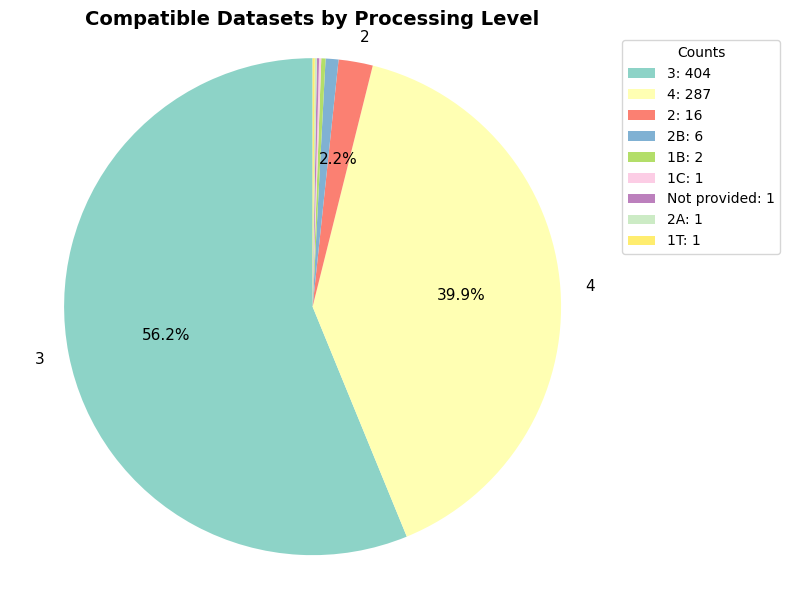

In [4]:
processing_level_counts = compatible_datasets.processing_level.value_counts(
    dropna=False
)
processing_level_ids = processing_level_counts.index

plotting.create_pie_chart(
    labels=processing_level_ids,
    sizes=processing_level_counts,
    title="Compatible Datasets by Processing Level",
    legend=True,
    top_n=3,
)

### Compatible Datasets by File Extension

Not all datasets have the `format` attribute, so we assess format using the `extension` attribute.


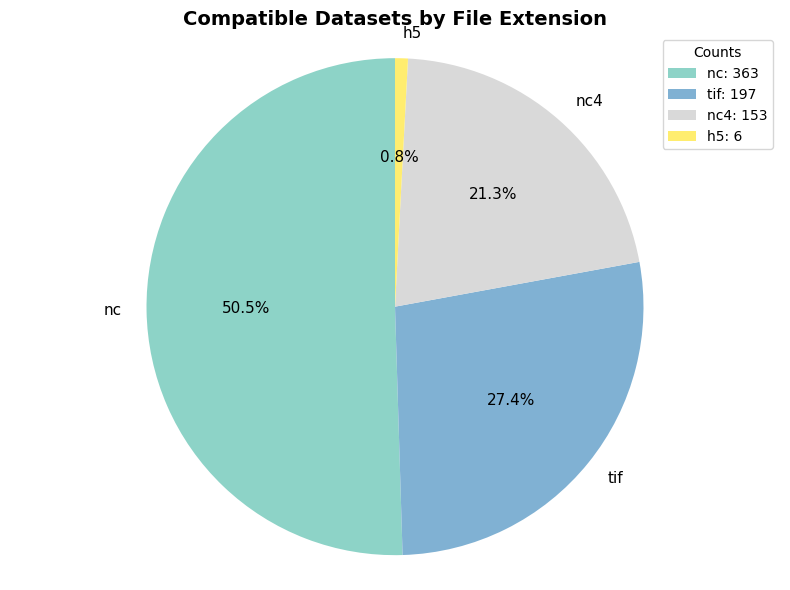

In [5]:
extension_counts = compatible_datasets.extension.value_counts(dropna=False)
extension_names = extension_counts.index

plotting.create_pie_chart(
    labels=extension_names,
    sizes=extension_counts,
    title="Compatible Datasets by File Extension",
    legend=True,
)

## What datasets are incompatible and why?

Only about 7% of datasets were found to be compatible. What's up with the other 93%?

The most common reason that datasets are deemed incompatible is because of an **unsupported format**.

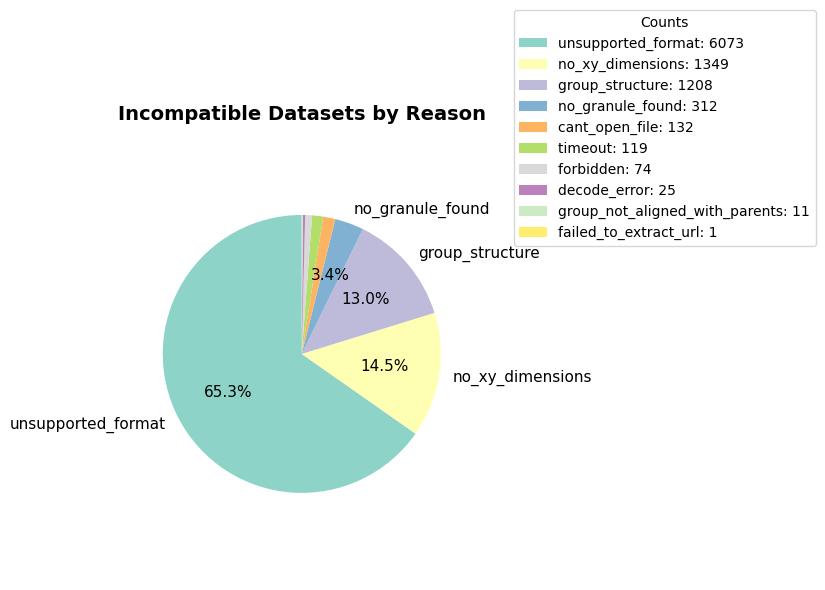

In [6]:
incompatible_reason_counts = df["incompatible_reason"].value_counts()
incompatible_reason_names = incompatible_reason_counts.index
incompatible_reason_counts.columns = ["Incompatible Reason", "Count"]
plotting.create_pie_chart(
    labels=incompatible_reason_names,
    sizes=incompatible_reason_counts,
    title="Incompatible Datasets by Reason",
    legend=True,
    top_n=4,
    legend_position="center left",
)

### Unsupported Formats

A majority of collections use an unsupported format. Supported formats and extensions were whitelisted, see [`titiler-cmr-compatibility's constants.py`](https://github.com/developmentseed/titiler-cmr-compatibility/blob/main/titiler_cmr_compatibility/constants.py).

#### Why are some formats considered "unsupported"?

The simple answer to this question is the backend libraries used by titiler (rio_tiler + rasterio or rio_tiler + xarray with h5netcdf or zarr backends) don't support formats.

A reasonable follow up question would be of course *Why don't these libraries support tiling more formats?* which requires a more long-winded answer:

1. **Library simplicity:** Software libraries have to balance flexibility with stability. Trying to support all functionality for all possible geospatial data formats will introduce complexity, making the libraries (titiler and rio_tiler in this case) harder to maintain.
2. **Lack of common geospatial structure:** Some formats (such as CSV, TXT, and ASCII) are categorically not supported because they lack a dependable structure for reading data into map tiles. This differs from formats like NetCDF, HDF, and GeoTIFF, which define geospatial coordinates in more consistent ways that mapping libraries can rely on (even if implementations are sometimes imperfect).
3. **Inefficient to read over the network:** NetCDF-3 and HDF4 were originally designed for reading from a local filesystem. Metadata is scattered throughout the file. Reading these files over a network connection is thus very slow given the hundreds of requests and responses required. While map tiles could be produced in theory, these non-cloud-optimized-formats make the process over the network prohibitively slow. rio_tiler has chosen to use xarray with the `h5netcdf` backend for simplicity and thus does not support reading these formats. GeoTIFFs are similarly inefficient to read over the network. While rio_tiler's rasterio reader could in theory download the entire GeoTIFFs to generate map tiles, it is extremely inefficient to do so and thus not supported.

#### How is the format determined?

To determine if a collection had files of a supported or unsupported format, `titiler-cmr-compatibility` uses collection and granule metadata. If no format property is present in the metadata, the file extension of the random sample granule is used.

Collections were classified as having an unsupported format when, in this order:

1. The format was explicitly defined in the metadata and that format was not in the list of supported formats.
2. If no format was specified in the metadata, the file extension was extracted and compared against the list of supported extensions.
3. Since not all file extensions fully describe the file format (for example, `.tif` could be a cloud-optimized or not-cloud-optimized GeoTIFF, and `.nc` could be NetCDF-4 or an earlier NetCDF version), the code proceeds to opening files which have an ambiguous file format. The code attempts to open all files with a file extension in the list of supported extensions. Sometimes this resulted in errors including the sub-strings `is not the signature of a valid netCDF4 file` or `Cannot seek streaming HTTP file`, indicating unsupported formats.

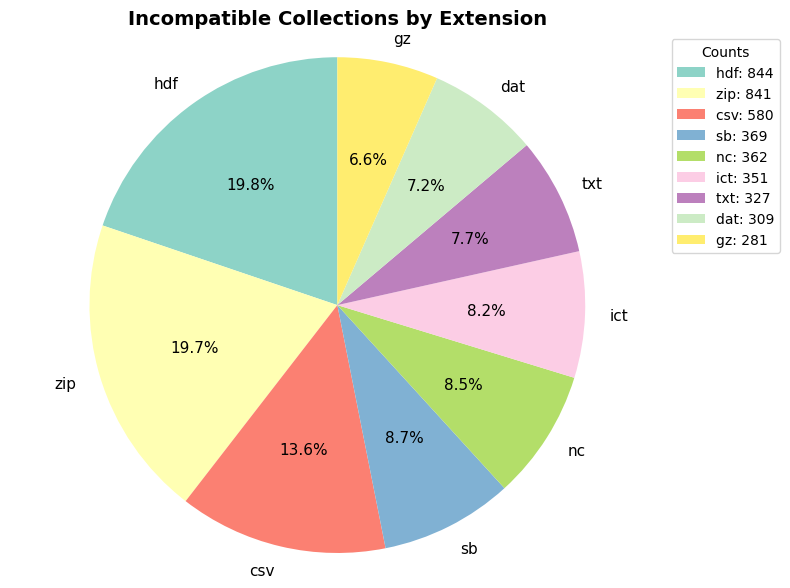

In [7]:
unsupported_format_subset_df = df[df["incompatible_reason"] == "unsupported_format"]
unsupported_extension_counts = unsupported_format_subset_df.extension.value_counts(
    dropna=False
)[0:9]
unsupported_extension_count_names = unsupported_extension_counts.index
plotting.create_pie_chart(
    labels=unsupported_extension_count_names,
    sizes=unsupported_extension_counts,
    title="Incompatible Collections by Extension",
    legend=True,
)

### No X,Y Dimensions

The second most common reason datasets were deemed incompatible was [titiler.xarray.io](https://github.com/developmentseed/titiler/blob/v0.25.0/src/titiler/xarray/titiler/xarray/io.py#L127) could not determine the x and y dimensions from the dimensions of the dataset. This represents a data characteristic issue rather than a technical limitation, as x, y dimensions are necessary to visualize data on a map.

However, many of these datasets are characterised as processing level 3 or 4. Further investigation could be warranted.

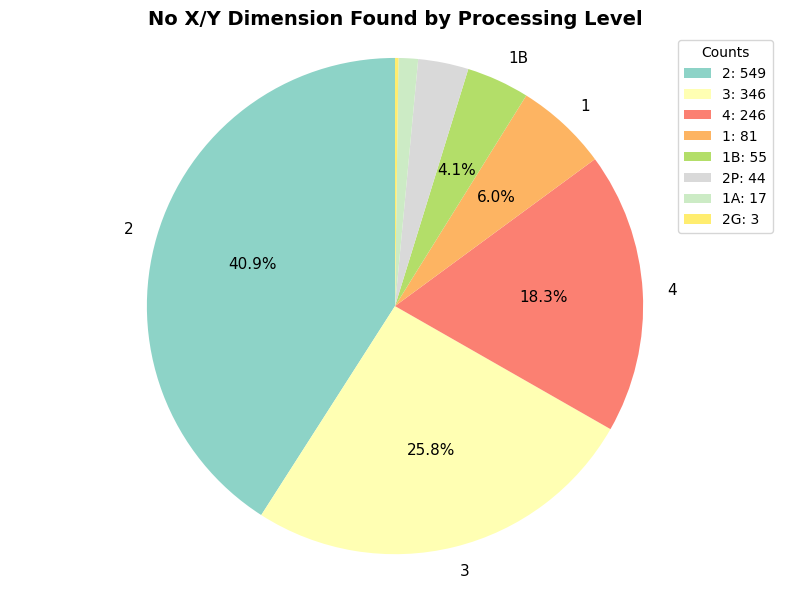

In [8]:
no_xy_dimensions_subset_df = df[df["incompatible_reason"] == "no_xy_dimensions"]
no_xy_counts = no_xy_dimensions_subset_df.processing_level.value_counts(dropna=False)[
    0:8
]
no_xy_count_names = no_xy_counts.index
plotting.create_pie_chart(
    labels=no_xy_count_names,
    sizes=no_xy_counts,
    title="No X/Y Dimension Found by Processing Level",
    legend=True,
    top_n=5,
)

### Group Structure

Many HDF5 and some NetCDF-4 datasets use a group (aka hierarchical structure). At the time of writing, files with groups are not supported by TiTiler-CMR, but support could easily be added in the near future.

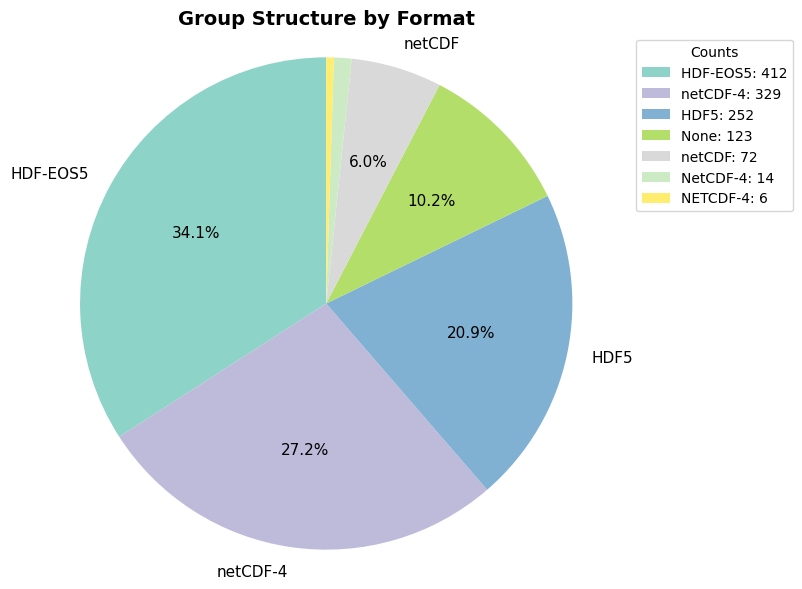

In [9]:
group_structure_subset_df = df[df["incompatible_reason"] == "group_structure"]
format_counts = group_structure_subset_df.format.value_counts(dropna=False)
format_counts_names = format_counts.index
plotting.create_pie_chart(
    labels=format_counts_names,
    sizes=format_counts,
    title="Group Structure by Format",
    legend=True,
    top_n=5,
)

### Other Incompatibility Issues

The rest of the datasets were deemed to be incompatible for the following reasons:

* No granules were returned from the CMR granules endpoint using the collection concept id.
* An error was thrown when attempting to open the file with xarray or rasterio. These errors, apart from those listed above, were often caused by various data-type related issues.
* `Forbidden` or `Unauthorized` errors.
* Timing out (each dataset was given 30 seconds to process).
* Out of memory (OOM) errors: these datasets are not represented in the results as OOM errors cause the lambda function to crash.

Timing out and OOM errors both signal that these datasets are potentially too large to enable dynamic tiling in an acceptable responsive time frame.

# Summary and Next Steps

While this process provides a nice listing and number of datasets that are compatible with TiTiler-CMR, individual datasets will still require testing and assessment. However, we are confident that compatible datasets could be identified as such through metadata.

Next steps:
* Support grouped datasets in TiTiler-CMR and re-run assessment.
* Discuss how to "publish" or otherwise advertise datasets that can be used with TiTiler-CMR.